In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

# Long's surface downward SW Rad

As suggested by Bill:

> If you would like to cross compare surface downwelling shortwave radiation, a good obs dataset to use is the qcradlong product (Long is a person's name and not just longwave radiation :slightly_smiling_face: ). You can find this data in the archive folder mounted to the jupyter server.

> QCRAD surface radiation product: /data/project/sgpqcrad1longE13.c2
Example file = sgpqcrad1longE13.c2.20180709.000000.cdf

> Note, I had trouble opening the file directly in xarray. If I first opened it with the netCDF4 library, then xarray worked. Don't know why...

In [8]:
import pandas as pd
SW_PATH = '/data/archive/sgp/sgpqcrad1longE13.c2/'

CASE_DATES = [20180709,
              20190517,
              20190919]

# SW_FILENAME = 'sgpqcrad1longE13.c2.20180709.000000.cdf'
SW_FILENAMES = [f'sgpqcrad1longE13.c2.{date}.000000.cdf' for date in CASE_DATES]

sw_dpscream_list = []
sw_lasso_list = []
for date in CASE_DATES:

    cur_day_fname = f'sgpqcrad1longE13.c2.{date}.000000.cdf'
    next_day_fname = f'sgpqcrad1longE13.c2.{date+1}.000000.cdf' # won;t work for end of month but these dates are convenient!
    sw_case = xr.open_mfdataset([SW_PATH+cur_day_fname, SW_PATH+next_day_fname]).BestEstimate_down_short_hemisp

    # now the case would start from 00:00UTC.

    # for DPSCREAM, data range is hourly from 13UTC to 3UTC the next day; temp res = 1h

    sw_case_dpscream = sw_case.isel(time=slice(13*60, (24+3+1)*60)).resample(time='1h').mean()
    sw_case_dpscream = sw_case_dpscream.assign_coords(time=sw_case_dpscream.time - pd.Timedelta(hours=6))
    sw_dpscream_list.append(sw_case_dpscream)


    # for LASSO, 06:00 - 21:00 local time UTC-6; temp res = 10min
    # so 12UTC to 27UTC (3UTC next day)
    sw_case_lasso = sw_case.isel(time=slice(12*60, (24+3+1)*60)).resample(time='10min').mean()
    sw_case_lasso = sw_case_lasso.assign_coords(time=sw_case_lasso.time - pd.Timedelta(hours=6))
    sw_lasso_list.append(sw_case_lasso)


sw_dpscream = xr.concat(
    sw_dpscream_list,
    dim='case'
)

sw_lasso = xr.concat(
    sw_lasso_list,
    dim='case'
)

    

## Usage:

`sw_dpscream` and `sw_lasso` DataArrays, specify case (0-2).

### Demo:

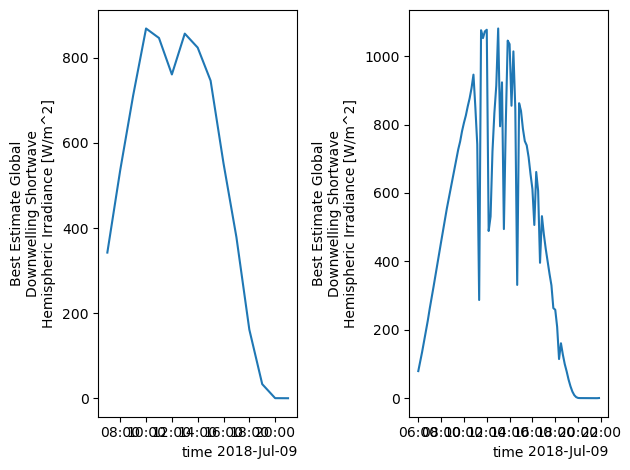

In [9]:
plt.subplot(1,2,1)
sw_dpscream.isel(case=0).plot()
plt.subplot(1,2,2)

sw_lasso.isel(case=0).plot()

plt.tight_layout()

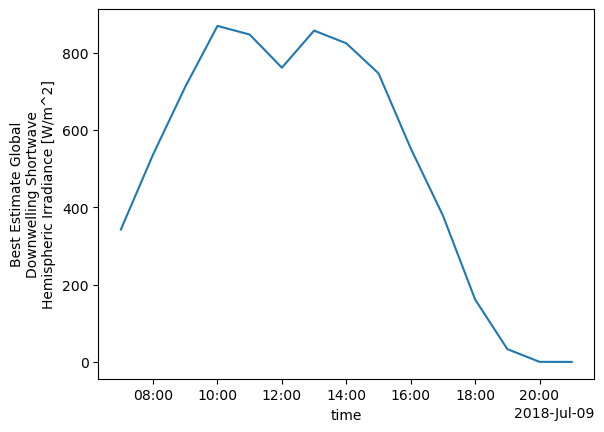

In [10]:
sw_dpscream.isel(case=0).plot()